In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hypermagnetics.fmm_sources import potential2D
from hypermagnetics.mt_eval import field_mt

In [ ]:
# ----- define a single 2D source -----
# magnetic moment vector (mx, my)
m = np.array([[[1.0, 1.0],
               [1.0,1.0]]])          # shape (1, N, 2) with N=2
m = m *2.0 # test different strengths

# centre position (x0, y0)
r0 = np.array([[[-2.0, -2.0],
                [2.0,2.0]]])         # shape (1, N, 2)

# size for source bodies
# for circles: (semimajor, semiminor) = (radius, radius)
# for ellipses???: (semimajor, semiminor)
# for prisms: (half-length-x, half-length-y)
size = np.array([[[1.0, 1.0],
                  [1.0,1.0]]])       # shape (1, N, 2); radius is size[..., 0]

# pack into `sources` so the last axis splits evenly into (m, r0, size)
sources = np.concatenate([m, r0, size], axis=-1)   # shape (1, N, 6)

# shape of source bodies
s_shape = "prism"

# ----- build grid in [-5, 5] with spacing 0.1 -----
dx = 0.1
xs = np.arange(-5.0, 5.0 + 1e-12, dx)
ys = np.arange(-5.0, 5.0 + 1e-12, dx)
X, Y = np.meshgrid(xs, ys, indexing="xy")
grid = np.column_stack([X.ravel(), Y.ravel()])     # shape (M, 2)

# ----- evaluate potential and field -----
# shape of outputs:
# msp:   (1, M, 1)
# field: (1, M, 2)   (Bx, By)
msp, field, _ = potential2D(
    sources,
    shape=s_shape,          # 2D circle case
    grid=grid,
    correction_source=False  # set True to apply inside-source correction
)


In [3]:
# Same field evaluation, but using MagTense
field_out_mt, dur_mt = field_mt(sources, grid, shape=s_shape, length=2)

In [4]:
# reshape for plotting
phi = msp[0][:].reshape(Y.shape)
Bx  = field[0][:, 0].reshape(Y.shape)
By  = field[0][:, 1].reshape(Y.shape)

Bx_mt  = field_out_mt[0][:, 0].reshape(Y.shape)
By_mt  = field_out_mt[0][:, 1].reshape(Y.shape)

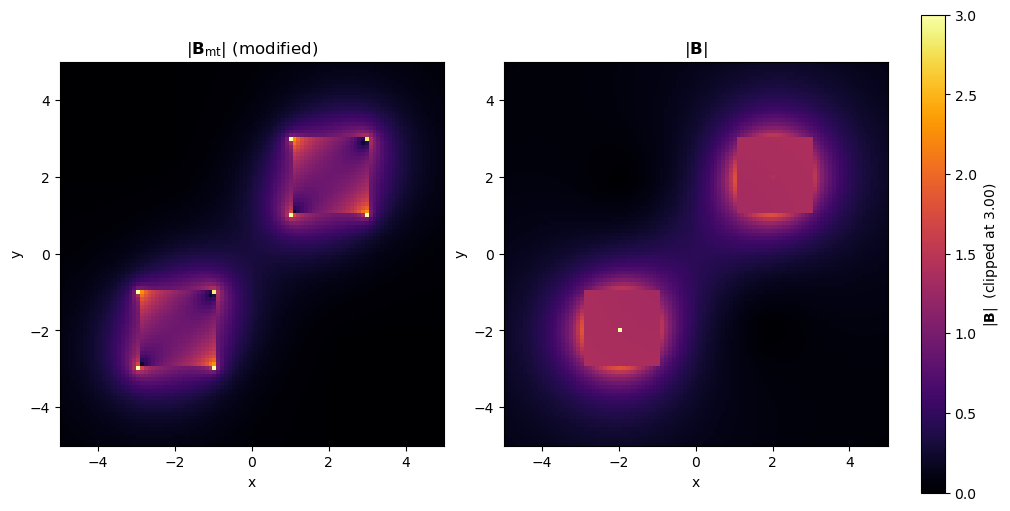

In [5]:
# ----- compute field magnitudes -----
B_tot_mt = np.sqrt(Bx_mt**2 + By_mt**2)
B_tot    = np.sqrt(Bx**2 + By**2)

# ----- clip for visual clarity -----
clip_val = 3.0
B_tot_mt_clipped = np.clip(B_tot_mt, 0, clip_val)
B_tot_clipped    = np.clip(B_tot,    0, clip_val)

# ----- plot side by side -----
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

# Left: modified field
im0 = axes[0].imshow(
    B_tot_mt_clipped,
    extent=(-5, 5, -5, 5),
    origin="lower",
    cmap="inferno",
    aspect="equal",
    vmin=0, vmax=clip_val
)
axes[0].set_title(r"$|{\bf B}_{\rm mt}|$ (modified)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Right: normal field
im1 = axes[1].imshow(
    B_tot_clipped,
    extent=(-5, 5, -5, 5),
    origin="lower",
    cmap="inferno",
    aspect="equal",
    vmin=0, vmax=clip_val
)
axes[1].set_title(r"$|{\bf B}|$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Shared colorbar
cbar = fig.colorbar(im1, ax=axes, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label(r"$|{\bf B}|$  (clipped at %.2f)" % clip_val)

plt.show()

Text(0.5, 1.0, 'Potential (single 2D dipole, r=1, m=(1,0))')

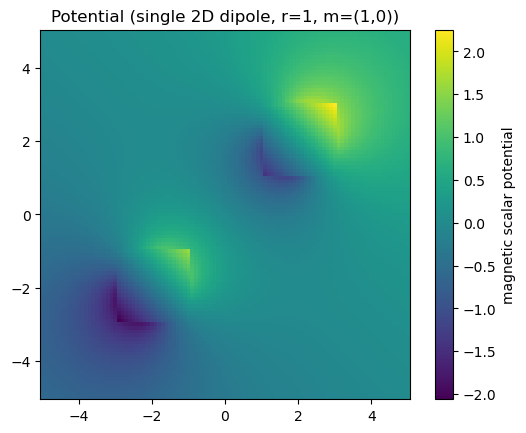

In [7]:
# quick visualisation (optional)
plt.figure()
plt.pcolormesh(X, Y, phi, shading="auto")
plt.colorbar(label="magnetic scalar potential")
plt.gca().set_aspect("equal")
plt.title("Potential (single 2D dipole, r=1, m=(1,0))")